
---

# 🧩 ***`Principal Component Analysis (PCA) in Python for Machine Learning & Data Science`*** 🚀  

## ✅ **What is PCA?**  

**Principal Component Analysis (PCA)** is a **dimensionality reduction** technique that transforms high-dimensional data into a **lower-dimensional space** while preserving as much variance as possible.

📌 **Key Idea:**  
- PCA finds **new axes** (principal components) that **capture the most variance** in the data.  
- Reduces redundancy by **removing correlated features**.  
- Helps in **visualization, noise reduction, and improving model performance**.  

---

## 🎯 **1. Why Use PCA?**  

✔ **Reduces dimensionality** → Avoids the **Curse of Dimensionality**.  
✔ **Speeds up ML models** → Less computation needed.  
✔ **Removes feature redundancy** → Eliminates correlated features.  
✔ **Improves visualization** → Projects data to 2D or 3D.  
✔ **Reduces noise** → Helps in denoising datasets.  

---

## 📊 **2. How Does PCA Work?**  

### **Step-by-Step Process:**  
1️⃣ **Standardize the Data** → Scale features (mean = 0, variance = 1).  
2️⃣ **Compute Covariance Matrix** → Measures relationships between features.  
3️⃣ **Find Eigenvalues & Eigenvectors** → Determines principal components.  
4️⃣ **Sort Principal Components** → Select the ones capturing most variance.  
5️⃣ **Project Data onto Principal Components** → Transform into lower dimensions.  

---

## 🛠 **3. PCA Implementation in Python**  

### 📁 **Dataset Example (Iris Dataset)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Load Dataset
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.target  # Adding target variable

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  



---
### 📏 **Step 1: Standardizing the Data**
```python

In [2]:
# Standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['Target']))


📌 **Why Standardize?**  
- PCA is **sensitive to scale** → Standardization ensures equal importance of all features.  

---

### 🔄 **Step 2: Applying PCA**

In [3]:
# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Target'] = df['Target']

print(df_pca.head())

        PC1       PC2  Target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0


📌 **Interpretation:**  
- `PC1` captures most variance, `PC2` captures second most.  
- Dimensionality is **reduced from 4 to 2** while preserving key patterns.  

---

### 📊 **Step 3: Visualizing PCA Results**

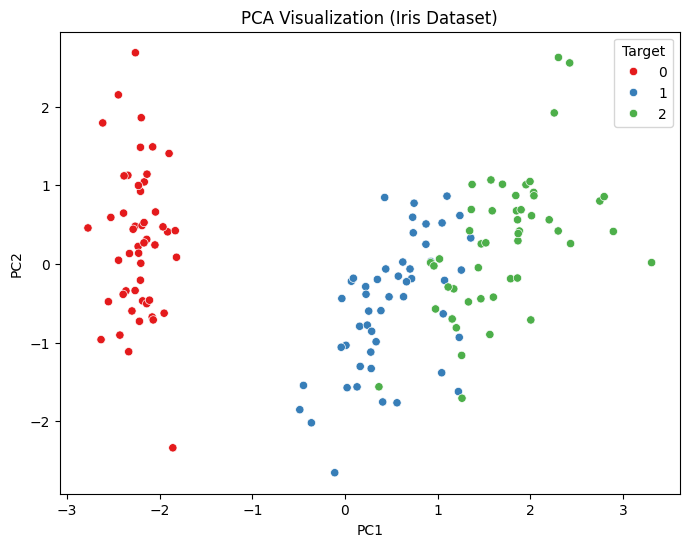

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['Target'], palette='Set1')
plt.title("PCA Visualization (Iris Dataset)")
plt.show()

📌 **Observations:**  
- PCA helps **visualize class separability**.  
- Useful for **clustering and classification models**.  

---

## 📉 **4. Choosing the Right Number of Principal Components**  

### **🔢 Step 1: Explained Variance Ratio**

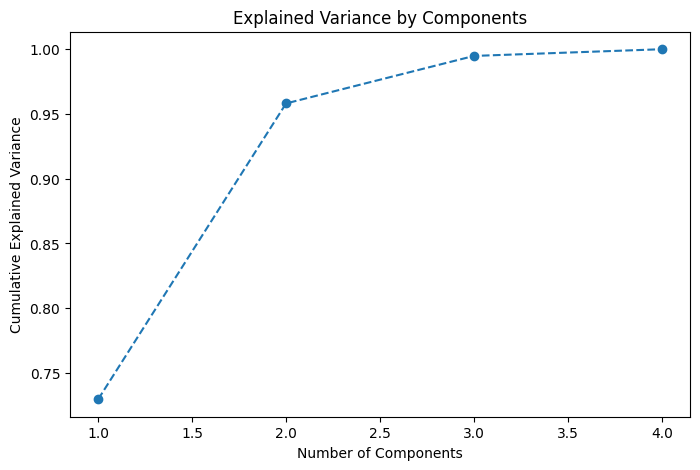

In [5]:
# Compute PCA for all components
pca_full = PCA().fit(X_scaled)

# Plot Explained Variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.show()


📊 **Key Takeaways:**  
- Choose components where **cumulative variance > 95%**.  
- In our case, **2 components** explain **most of the variance**.  

---

## 🎯 **5. PCA for Machine Learning Models**  

### **Using PCA in an ML Pipeline (Random Forest Example)**

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['Target'], test_size=0.2, random_state=42)

# Create Pipeline with PCA & Classifier
pipeline = Pipeline([
    ('pca', PCA(n_components=2)),  # Reduce to 2D
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train Model
pipeline.fit(X_train, y_train)

# Evaluate Model
accuracy = pipeline.score(X_test, y_test)
print("Model Accuracy with PCA:", accuracy)

Model Accuracy with PCA: 0.9


📌 **Why Use PCA in Pipelines?**  
- Ensures **consistent transformations** between train & test data.  
- **Speeds up training** while maintaining accuracy.  

---

## 🏆 **6. When to Use PCA?**  

✅ **Use PCA When:**
- **Dataset has many features** and **some are redundant**.  
- **Computational efficiency** is important.  
- **Overfitting** is a concern due to high-dimensional data.  
- **Visualization** is needed (e.g., reducing to 2D for plots).  

❌ **Avoid PCA When:**
- Features have **strong interpretability** (e.g., age, income).  
- **Linear relationships** don’t exist between features.  
- The dataset is already **small** (dimensionality reduction isn’t needed).  

---

## 📊 **7. PCA vs. Feature Selection**  

| **Feature Selection** | **PCA (Feature Extraction)** |
|----------------------|----------------------------|
| Keeps original features | Creates **new transformed features** |
| Selects **most important** features | Finds **new axes (principal components)** |
| Works well when features are independent | Works well when features are correlated |
| Improves model interpretability | Hard to interpret principal components |

📌 **Use Feature Selection for explainability, PCA for redundancy removal.**  

---

## 🎯 **8. Key Takeaways**  

✔ **PCA reduces dimensionality while preserving maximum variance.**  
✔ **Standardization is required** before applying PCA.  
✔ **Use PCA when dealing with high-dimensional, correlated features.**  
✔ **Select components that explain >95% variance** to balance performance & speed.  
✔ **Use PCA in ML Pipelines** for automated dimensionality reduction.  

💡 **Pro Tip:** Always check the **explained variance** before deciding on the number of principal components!

---